In [1]:
import scipy
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
def kernel_func(xa, xb):
    xa = xa.reshape(-1,1)
    xb = xb.reshape(-1,1)
    sq_norm = -0.5 * scipy.spatial.distance.cdist(xa, xb, 'sqeuclidean')
    return np.exp(sq_norm)

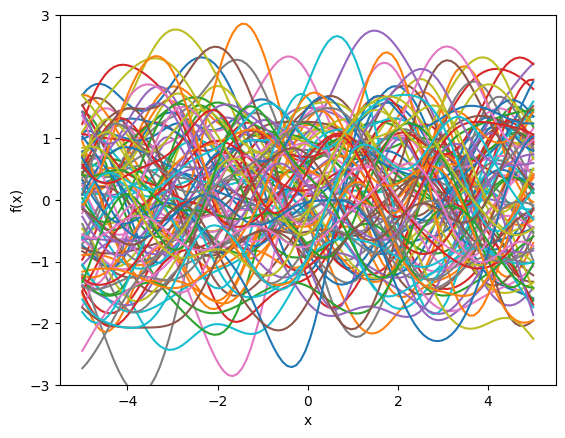

In [3]:
x = np.linspace(-5,5,100)
n_samples = len(x)
K = kernel_func(x, x)
var = np.diag(K)
sd_ = np.sqrt(var)
mean_prior = np.zeros(n_samples)

for i in range(0,100):
    f = np.random.multivariate_normal(mean = mean_prior,cov = K)
    plt.plot(x,f)
    

y_up = mean_prior+2*sd_
y_down = mean_prior-2*sd_

# plt.plot(x,y_up,'black')
# plt.plot(x,y_down,'black')
# plt.fill_between(x,y_up,y_down,alpha=0.1,color = 'gray')

plt.ylim(-3,3)
plt.grid(False)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

(100,)


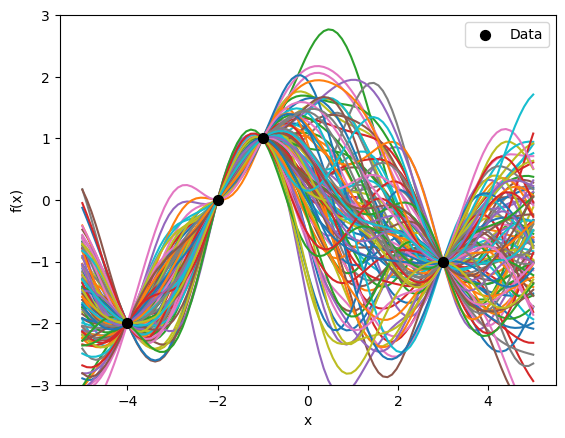

In [7]:
X_train = np.array([-4,-2,-1,3])
y_train = np.array([-2,0,1,-1])
mean_y = np.mean(y_train)
y = y_train-mean_y

X_test = np.linspace(-5,5,100)
K_data = kernel_func(X_train,X_train)
K_test = kernel_func(X_test,X_train)
K_data_inv = np.linalg.inv(K_data)

mean_pred = np.dot(np.dot(K_test,K_data_inv),y) + mean_y

# Uncertianty in predictions
K_test_2 = kernel_func(X_test, X_test)
Cov_pred = K_test_2 - np.dot(np.dot(K_test, K_data_inv),np.transpose(K_test))
std_pred = np.sqrt(np.diag(Cov_pred))

print(std_pred.shape)

for i in range(0,100):
    f = np.random.multivariate_normal(mean = mean_pred,cov = Cov_pred)
    plt.plot(X_test,f)

plt.scatter(X_train,y_train,s = 50, c='black',label = 'Data',zorder=2)
# plt.plot(X_test,mean_pred)
y_up = mean_pred+2*std_pred
y_down = mean_pred-2*std_pred

# plt.plot(x,y_up,'black')
# plt.plot(x,y_down,'black')
# plt.fill_between(x,y_up,y_down,alpha=0.1,color = 'gray')

plt.ylim(-3,3)
plt.grid(False)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()